In [7]:
# importing libraries

import cv2
import matplotlib.pyplot as plt
import numpy as np 


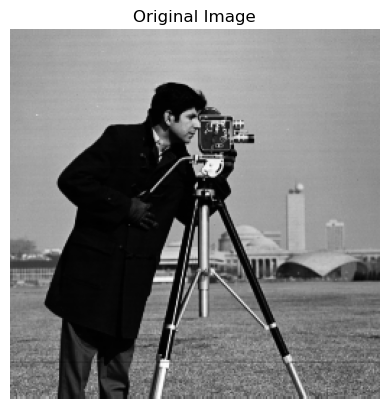

In [15]:
#reading the image
img=cv2.imread('cameraman.png',0) # grayscale the image if not grayscale by using 0
img=cv2.resize(img,(256,256))

#flattening the image
# Convert 2D image into 1D sequence for transmission
x = img.flatten() #image array

#Plotting the image
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.title("Original Image")
plt.show()


Total number of bits = 524288


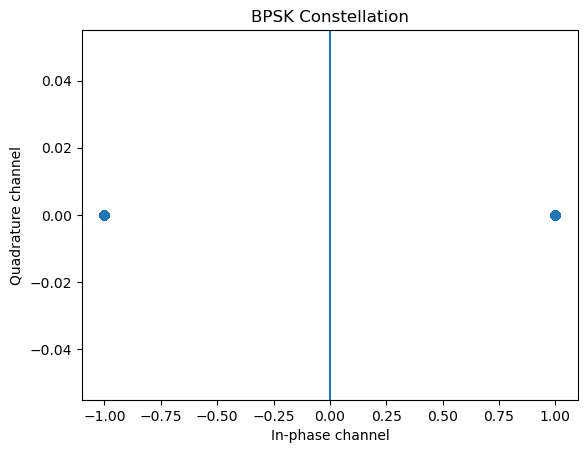

In [16]:
# Initialize an empty list to store the bitstream
bitstream = []

# Loop through each pixel value in the flattened image array x
for pixel in x:
    # Convert pixel (0–255) to 8-bit binary string (PCM encoding)
    bits = format(int(pixel), '08b')
    
    # Convert each bit ('0' or '1') to integer and add to bitstream
    bitstream.extend([int(b) for b in bits])

# Convert list to numpy array for easier processing
bitstream = np.array(bitstream)

# Print total number of bits generated
print(f'Total number of bits = {len(bitstream)}')


# ----------- BPSK MAPPING -----------

# Map bits to BPSK symbols:
# Here: 0 → +1 and 1 → -1 (your mapping)
a = np.where(bitstream == 0, 1, -1)


# ----------- CONSTELLATION PLOT -----------

# Plot first 1000 symbols on I-axis (Q = 0 since BPSK is 1D)
plt.scatter(a[:1000], np.zeros(1000))

# Title of the plot
plt.title('BPSK Constellation')

# Label for X-axis (In-phase component)
plt.xlabel('In-phase channel')

# Label for Y-axis (Quadrature component - zero for BPSK)
plt.ylabel('Quadrature channel')

# Draw vertical line at 0 (decision boundary)
plt.axvline(0)

# Display the plot
plt.show()

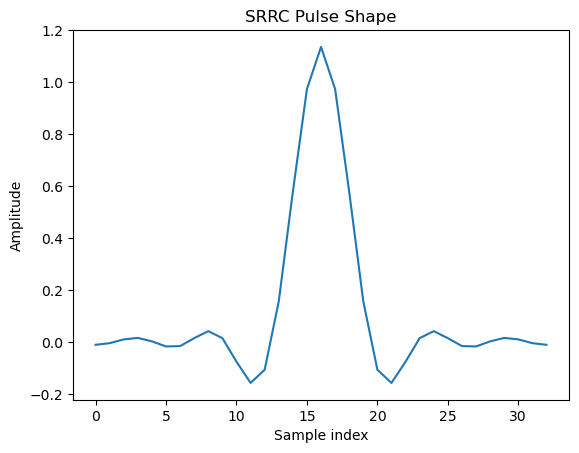

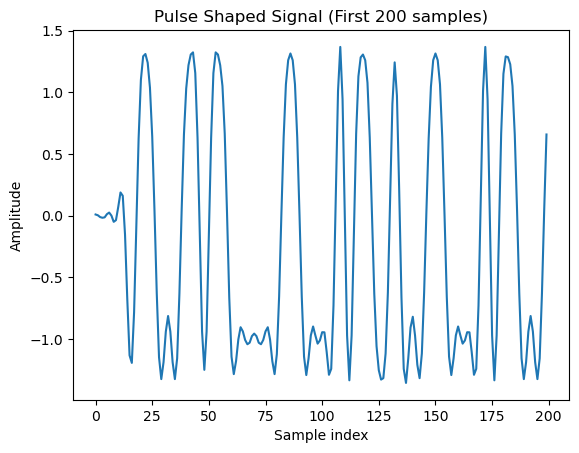

In [17]:
# ----------- PARAMETERS -----------

L = 4          # Upsampling factor (number of samples per symbol)
Nsym = 8       # Pulse span in number of symbols
Tsym = 1       # Symbol duration
B = 0.5        # Roll-off factor (beta for SRRC)


# ----------- UPSAMPLING -----------

# Create a zero array with length = number of symbols * L
u = np.zeros(len(a) * L)

# Insert symbols at every L-th position, rest are zeros
for i in range(len(a)):
    u[i * L] = a[i]

# Now u[n] is an impulse train (symbols separated by zeros)


# ----------- TIME VECTOR FOR SRRC -----------

# Generate time samples from -Nsym/2 to +Nsym/2 with step 1/L
T = np.arange(-Nsym/2, Nsym/2 + 1/L, 1/L)


# ----------- SRRC PULSE GENERATION -----------

p = []   # list to store pulse samples

for t in T:
    
    # Case 1: t = 0 (special case to avoid division by zero)
    if t == 0:
        p.append((1 + B * (4 / np.pi - 1)) / np.sqrt(Tsym))
    
    # Case 2: t = ±Tsym/(4B) (another special case)
    elif t == Tsym / (4 * B) or t == -Tsym / (4 * B):
        p.append(
            B * (
                (1 + 2 / np.pi) * np.sin(np.pi / (4 * B)) +
                (1 - 2 / np.pi) * np.cos(np.pi / (4 * B))
            ) / np.sqrt(2 * Tsym)
        )
    
    # Case 3: General SRRC formula
    else:
        p.append(
            4 * B * (
                np.cos((1 + B) * np.pi * t / Tsym) +
                (Tsym / (4 * B * t)) * np.sin((1 - B) * np.pi * t / Tsym)
            ) / (
                (1 - (4 * B * t / Tsym) ** 2) * np.pi * np.sqrt(Tsym)
            )
        )

# Convert list to numpy array
p = np.array(p)


# ----------- PLOT SRRC PULSE -----------

# Plot SRRC pulse shape
plt.plot(np.arange(len(p)), p)
plt.title("SRRC Pulse Shape")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()


# ----------- TRANSMIT SIGNAL (PULSE SHAPING) -----------

# Convolve upsampled signal with SRRC pulse
s = np.convolve(u, p)

# s[n] is the transmitted signal after pulse shaping


# ----------- PLOT TRANSMITTED SIGNAL -----------

# Plot first 200 samples to visualize shaped waveform
plt.plot(s[:200])
plt.title("Pulse Shaped Signal (First 200 samples)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()

BER value for SNR = 0 dB = 0.06633567810058594


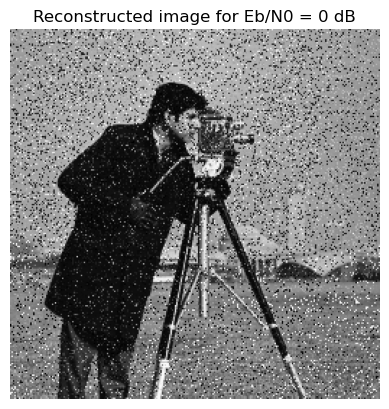

BER value for SNR = 2 dB = 0.03718376159667969


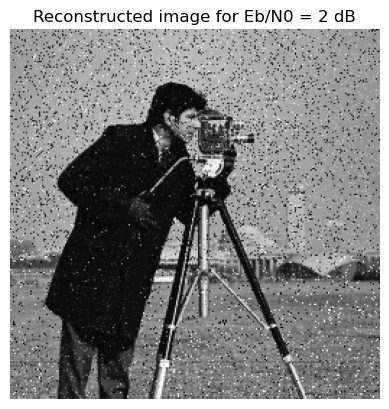

BER value for SNR = 4 dB = 0.018495559692382812


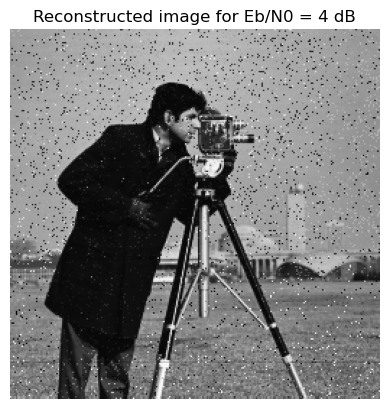

BER value for SNR = 6 dB = 0.007297515869140625


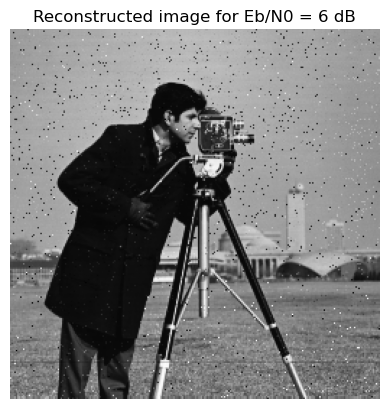

BER value for SNR = 8 dB = 0.0021038055419921875


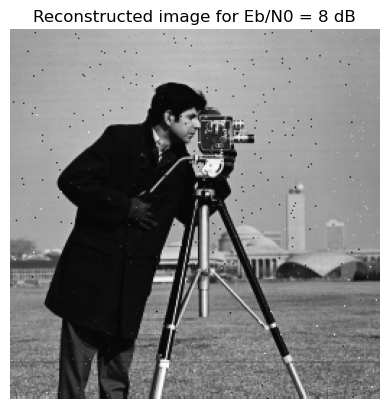

BER value for SNR = 10 dB = 0.0003833770751953125


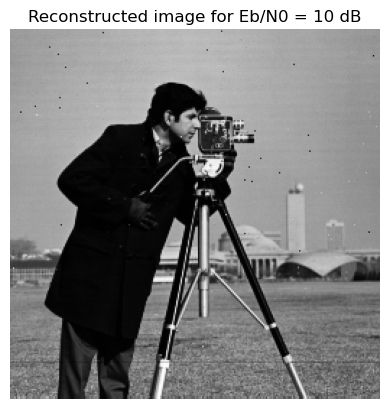

BER value for SNR = 12 dB = 3.814697265625e-05


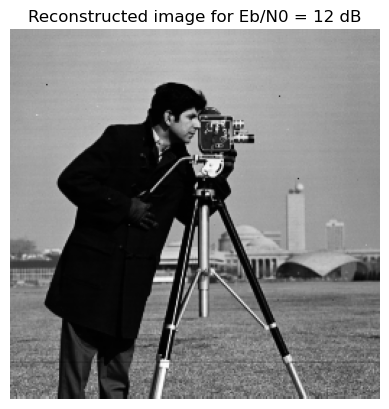

BER value for SNR = 14 dB = 0.0


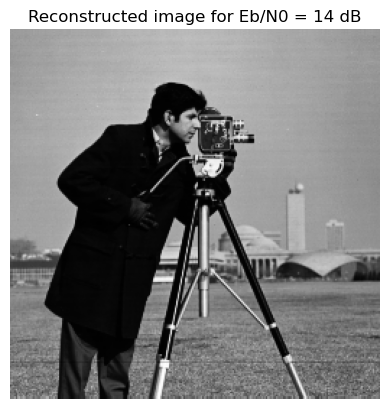

BER value for SNR = 16 dB = 0.0


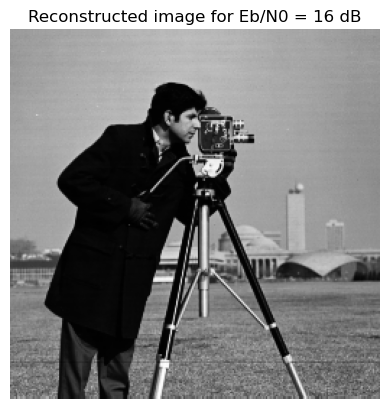

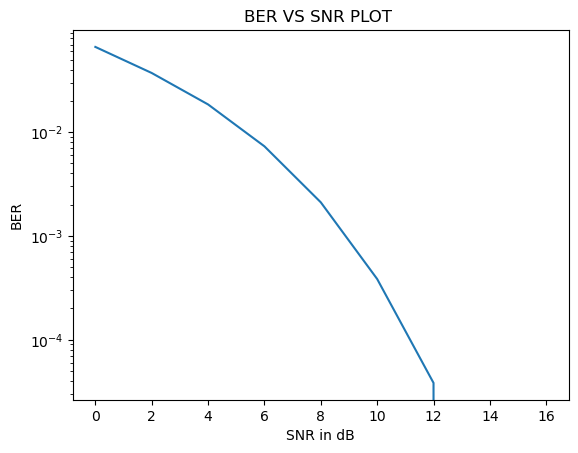

In [19]:
# ----------- SNR VALUES -----------

# List of SNR values in dB for simulation
SNR = [0,2,4,6,8,10,12,14,16]


# ----------- SIGNAL POWER -----------

# Compute average power of transmitted signal s[n]
Ps = (1/len(s)) * np.sum(np.abs(s)**2)


# List to store BER values for different SNRs
BER_sim = []


# ----------- LOOP OVER SNR VALUES -----------

for i in SNR:
    
    # Convert SNR from dB to linear scale
    SNR_lin = 10**(i/10)
    
    # Compute required noise power
    Pn = Ps / SNR_lin
    
    # Generate AWGN noise with variance = Pn
    w = np.sqrt(Pn) * np.random.normal(0, 1, len(s))
    
    # Add noise to transmitted signal
    r = s + w


    # ----------- MATCHED FILTER -----------

    # Matched filter (same as SRRC since symmetric)
    g = p
    
    # Convolve received signal with matched filter
    y = np.convolve(r, g)


    # ----------- DOWNSAMPLING -----------

    arx = []
    
    # Sample every L-th point (symbol recovery)
    # Starting from len(p) approximates delay compensation
    for j in range(len(p), len(y)+1, L):
        arx.append(y[j])
    
    # Convert to numpy array
    arx = np.array(arx)


    # ----------- BPSK DEMAPPING -----------

    # Decision rule:
    # If value >= 0 → bit = 0
    # If value < 0 → bit = 1
    brx = np.where(arx >= 0, 0, 1)
    
    # Trim extra bits (due to convolution length increase)
    brx = brx[:len(bitstream)]


    # ----------- BER CALCULATION -----------

    # Count number of bit errors
    bit_errors = np.sum(bitstream != brx[:len(bitstream)])
    
    # Compute Bit Error Rate
    BER = bit_errors / len(bitstream)
    
    # Store BER value
    BER_sim.append(BER)
    
    # Print BER for current SNR
    print(f'BER value for SNR = {i} dB = {BER}')


    # ----------- RECONSTRUCT IMAGE -----------

    # Group bits into 8-bit words (each pixel)
    brx_reshaped = brx.reshape(-1, 8)
    
    pixel_rx = []
    
    # Convert each 8-bit word back to integer pixel value
    for byte in brx_reshaped:
        value = 0
        
        for bit in byte:
            # Shift left and add new bit (binary to decimal)
            value = (value << 1) | bit
        
        pixel_rx.append(value)
    
    # Convert to numpy array
    pixel_rx = np.array(pixel_rx)
    
    # Reshape back to 256x256 image
    img_rx = pixel_rx.reshape(256, 256)


    # ----------- DISPLAY IMAGE -----------

    plt.figure()
    plt.imshow(img_rx, cmap='gray')
    plt.title(f'Reconstructed image for Eb/N0 = {i} dB')
    plt.axis('off')
    plt.show()


plt.title(f"BER VS SNR PLOT ")
plt.xlabel("SNR in dB")
plt.ylabel("BER")
plt.semilogy(SNR,BER_sim)
plt.show()




